<a href="https://colab.research.google.com/github/Raskovm/Detector_de_emociones/blob/main/OS_Detector_de_Emotiones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Máquinas de Soporte Vectorial

## Instalar las librerias faltantes

In [ ]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 9.9 MB/s eta 0:00:00


In [ ]:
!pip install unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.5/235.5 kB 5.3 MB/s eta 0:00:00


## Importar librerias necesarias

In [ ]:
import pandas as pd
import emoji
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from nltk import PorterStemmer, word_tokenize
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
import re
from unidecode import unidecode
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import numpy as np
import itertools
from sklearn.naive_bayes import MultinomialNB, GaussianNB
import pickle
import snowballstemmer
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report


# Download NLTK's resources (They download everything from nltk, but with just these two the work is done, which means, less memory and time used)
nltk.download('stopwords')
nltk.download('punkt')
#nltk.download("all")
nltk.download('punkt_tab')

# Initialize SnowballStemmer
stemmer = SnowballStemmer('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## Introducción

La detección de emociones es un subcampo del análisis de sentimientos y se ocupa de detectar las emociones de quien escribe a partir de datos del texto. La principal diferencia entre ambos es que, mientras que el análisis de sentimientos intenta clasificar un texto como positivo o negativo, la detección de emociones intenta identificar la emoción exacta de la persona, como felicidad, tristeza, miedo, etc.

El análisis de las emociones de los tweets es una tarea muy desafiante para los sistemas de procesamiento del lenguaje natural. A diferencia del texto tradicional, los tweets son mensajes muy cortos y contienen errores ortográficos, jerga, formas abreviadas, abreviaturas de frases, alargamientos expresivos y sarcasmo.

La identificación automática de las emociones expresadas en los datos de Twitter tiene una amplia gama de aplicaciones, como comprender las opiniones de las personas consumidoras sobre un producto, detectar trastornos depresivos o identificar amenazas terroristas.

## Bases de datos

El conjunto de datos utilizado para el entrenamiento y la evaluación de las emociones en los tweets se extrajo en parte del conjunto de datos WASSA, que se ofreció a las personas participantes en el Taller sobre Enfoques Computacionales de la Subjetividad, el Sentimiento y el Análisis de Redes Sociales (WASSA-2017, por sus siglas en ingles).

1,350 tweets fueron extraidos para cada una de las cuatro emociones: miedo, tristeza, alegría e ira, sin tener en cuenta los datos que contienen intensidades de las emociones. Junto a estas cuatro clases, se agregó una clase extra de 1,350 tweets neutrales; se ha demostrado que tener una clase neutral en el proceso de clasificación es importante, porque de esta manera la red neuronal no tendrá que clasificar emociones desconocidas en una de las clases de emociones aprendidas.

Los tweets neutrales se extrajeron de CrowdFlower, la cual es líder mundial del crowdsourcing. El crowdsourcing es obtener trabajo, información u opiniones de un gran grupo de personas que envían sus datos a través de Internet, redes sociales y aplicaciones de teléfonos inteligentes. Las personas involucradas en el crowdsourcing a veces trabajan como autónomos remunerados, mientras que otras realizan pequeñas tareas de forma voluntaria.

La razón por la que se dividió el conjunto de datos de esta manera es la importancia de tener un conjunto de datos bien equilibrado. Un conjunto de datos bien equilibrado contiene la misma cantidad de muestras por clase. Esto asegura que el modelo no favorecerá a clases más grandes en el proceso de clasificación, evitando sesgos.

La proporción de datos de entrenamiento-evaluación, es: 1200 muestras para el entrenamiento y 150 para la evaluación, para cada emoción.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/taller/emotion_tweets.csv")
df = df.loc[df['emotion'] != 'neutral']

In [ ]:
np.unique(df['emotion'])

array(['anger', 'fear', 'joy', 'sadness'], dtype=object)

In [ ]:
df

,tweet,emotion
0,Kinda wished I watched mischievous kiss before...,joy
1,When you forget to mention you were bought dre...,anger
4,Some moving clips on youtube tonight of the vi...,anger
5,Do what makes you successful and #happy now an...,joy
7,Standard Candice starting the show with a pout...,sadness
...,...,...
7495,#India right of reply at #UNGA - #Pakistan pre...,fear
7496,@TicciKasie1 //this is sadly what my history t...,sadness
7497,So not pumped for this interview #nervous,fear
7498,Follow this amazing Australian author @KristyB...,fear


# Preprocesamiento

## Representación

Definiremos la función **preprocess_text** para realizar el preprocesamiento necesario a las bases de datos.

La función consiste de lo siguiente:
1. Eliminar los nombres de usuario, enlaces y símbolos de hashtag
2. Conversión de emojis a palabras
3. Conversión de Unicode a ASCII
4. Tokenización
5. Filtrado de palabras comunes

Los nombres de usuario, enlaces y símbolos de hashtag son irrelevantes para detectar la emoción en un tweet, por eso son eliminados. Un casó sería, 'https://theuselessweb.com/ #Dope @Rafuki' el cual regresaría solo Dope, porque el contenido de los hashtags podría tener relevancia.

La conversión de emojis a palabras es relevante para detectar la emoción en un tweet, ya que se utilizan con frecuencia en mensajes de texto para transmitir mejor los sentimientos. Se utilizó la biblioteca **emoji** de Python para emojis Unicode. Por ejemplo, la conversión de 😛 es :face_with_tongue: y 🤣 es :rolling_on_the_floor_laughing:

La conversión de Unicode a ASCII se consideró importante ya que el conjunto de caracteres ASCII es más pequeño en comparación con el Unicode, por lo tanto, el tiempo de cálculo se reduce, debido a que el recuento de palabras también se reducirá, lo que podría resultar en un aumento del rendimiento. Para más información de Unicode y ASCII ver el siguiente link: https://www.geeksforgeeks.org/ascii-vs-unicode/

La tokenización es una tarea común en el procesamiento del lenguaje natural (NLP). Es un paso fundamental tanto en métodos tradicionales como Count Vectorizer como en arquitecturas basadas en Deep Learning como RNN o Transformers. Dada una secuencia de caracteres y una unidad de documento definida, la tokenización es la tarea de 'cortarla en pedazos', llamados tokens, referidos como términos o palabras, quizás al mismo tiempo desechar ciertos caracteres, como la puntuación. Por ejemplo, el texto 'Do you have depression?' se volvería estos tokens 'Do', 'you', 'have', 'depression', '?'.

Las palabras comunes (StopWords) son utilizadas frecuentemente en un idioma, en este caso que lo hacemos en inglés, artículos (a, an, the), preposiciones (of, in, for, through) y pronombres (it, their, his). Se usan normalmente en minería de textos y NLP para eliminar palabras que se usan tan ampliamente que llevan muy poca información útil. El filtrado de estas en el conjunto de datos mejora el rendimiento y acelera el cálculo, por lo que se utilizó la lista de palabras comunes de nltk para esta tarea.

La derivación léxica (stemming) es el proceso de reducir la palabra a su raíz, conocida como lema, por ejemplo, las palabras "depress", "depressed" y "depression" se encuentran bajo la misma raíz "depress". Este es otro método para mejorar el rendimiento del modelo. Se utilizó el stemmer Snowball de nltk, una demostración de su uso es con los tokens del texto 'Do you have depression?', regresaría únicamente 'depress'.

## Ejemplo alegre en imagen de eliminación de stopwords, tokenización y stemming

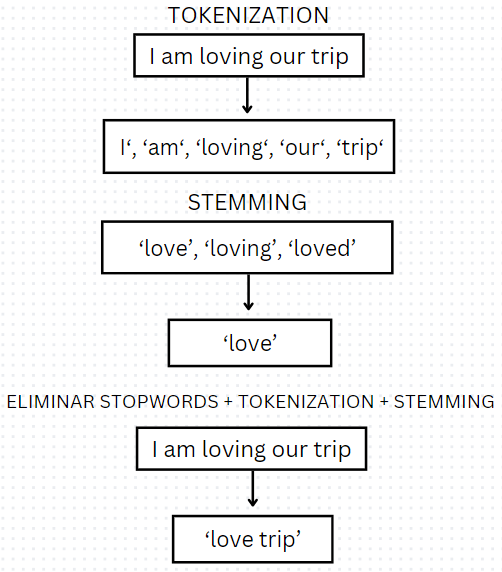

# PREGUNTAS

**En el caso de esta tarea, ¿por qué eliminar las stopwords y realizar tokenización más stemming es importante?**

La tokenización divide el texto en palabras individualesEliminar palabras vacías (palabras vacías como “the”, “is”, “in”) reduce el ruido en el texto, permitiendo que el modelo se enfoque en las palabras que realmente aportan información.
La tokenización divide el texto en palabras individuales para analizarlas mejor, y el stemming reduce las palabras a su raízreduce las palabras a su raíz, unificando formas distintas como “watching” , “watched” y “watch” .
En conjunto, esto mejora la eficiencia del modelo y su capacidad para detectar patrones importantes en los datos.

**¿Consideras que TF-IDF es un método fiable para medir la relevancia de un palabra? Argumenta tu respuesta**

Sí, TF-IDF es un método confiable en muchos casos , porque combina dos factores:

- TF : mide cuantas veces aparece una palabra en un documento.

- IDF : penalizapenaliza palabras comunes en todos los documentos, destacando las que son únicas o más informativas .

Esto hace que TF-IDF identifique bien qué palabras ayudan a diferenciar un documento de otros. Sin embargo, tiene limitaciones: no capta contexto ni relaciones semánticas entre palabras, por lo que a veces se complementa con técnicas más avanzadas como incrustaciones.

In [ ]:
# Define the preprocess_text function
def preprocess_text(text):
    # Function to translate emojis in a sentence
    def translate_sentence_with_emojis(sentence):
        translated_sentence = ""
        words = sentence.split()
        for word in words:
            if any(emoji.is_emoji(c) for c in word):
                translated_word = emoji.demojize(word)
                translated_sentence += translated_word + " "
            else:
                translated_sentence += word + " "
        return translated_sentence.strip()

    # Remove usernames starting with @
    text = re.sub(r'@[^\s]+', '', text)
    # Remove links starting with http or https
    text = re.sub(r'https?://\S+', '', text)
    # Remove hashtags
    text = re.sub(r'#', '', text)
    # Translate emojis
    text = translate_sentence_with_emojis(text)
    # Convert Unicode to ASCII
    text = unidecode(text)
    # Remove stopwords and stem words
    stop_words = set(stopwords.words('english'))
    word_tokens = word_tokenize(text)
    filtered_text = [word for word in word_tokens if word.lower() not in stop_words]
    stemmed_text = [stemmer.stem(word) for word in filtered_text]
    # Tokenize text
    tokens = nltk.word_tokenize(' '.join(stemmed_text))
    cleaned_tokens = [re.sub(r'[^a-zA-Z]', '', token) for token in tokens]
    cleaned_tokens = [token for token in cleaned_tokens if token]  # Remove empty tokens
    return ' '.join(cleaned_tokens)

In [ ]:
# Apply the preprocessing function to the 'tweets' column
df['cleaned_tweet'] = df['tweet'].apply(preprocess_text)

In [ ]:
df

,tweet,emotion,cleaned_tweet
0,Kinda wished I watched mischievous kiss before...,joy,kinda wish watch mischiev kiss play kiss
1,When you forget to mention you were bought dre...,anger,forget mention bought dreamboy ticket facewith...
4,Some moving clips on youtube tonight of the vi...,anger,move clip youtub tonight vigil held tulsa metr...
5,Do what makes you successful and #happy now an...,joy,make success happi forev
7,Standard Candice starting the show with a pout...,sadness,standard candic start show pout startasyoumean...
...,...,...,...
7495,#India right of reply at #UNGA - #Pakistan pre...,fear,india right repli unga pakistan preach human r...
7496,@TicciKasie1 //this is sadly what my history t...,sadness,this sad histori teacher talk fuck rememb
7497,So not pumped for this interview #nervous,fear,pump interview nervous
7498,Follow this amazing Australian author @KristyB...,fear,follow amaz australian author fiction horror z...


## Encoding

Ahora procederemos a vectorizar las oraciones con TF-IDF y codificar las etiquetas con LabelEncoder.

La frecuencia del término (TF) de una palabra es la cantidad de veces que aparece en un documento en comparación con la cantidad total de palabras en el documento. Por ejemplo, supongamos que en un documento de 100 palabras la palabra 'depress' aparece 20 veces, el TF sería, 20/100 = 0.2

Por otro lado, la frecuencia inversa de documentos (IDF) de un término refleja la proporción de documentos en el corpus que contienen la palabra, en el IDF la transformación logarítmica se utiliza para escalar los valores para que estén distribuidos de manera más uniforme y sea más fácil trabajar con ellos en tareas posteriores de aprendizaje automático. Por ejemplo, asumiendo que el corpus se compone de 10,000 documentos y la palabra 'depress' aparece en 100 de ellos, su IDF sería, log(10000/100) = 2

Por último, el TF-IDF de una palabra se calcula multiplicando las puntuaciones TF e IDF; utilizando el ejemplo dado, quedaría, 0.2*2 = 0.4, indicando que tiene una importancia moderada. Mientras más alto sea la puntuación del TF-IDF, mayor importancia o relevancia tiene la palabra.

Aplicando todo lo anterior descrito, se crea un vector numerico para cada documento, que en este caso sería para cada tweet. Para más información de TF-IDF y su implementación en Python, ver el siguiente link: https://www.learndatasci.com/glossary/tf-idf-term-frequency-inverse-document-frequency/

In [ ]:
# Vectorize the tweets data
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(df["cleaned_tweet"].tolist())

Después de vectorizar el corpus mediante el TfidfVectorizer(), se obtiene una matriz dispersa. Una matriz dispersa es un caso especial de matriz en la que el número de elementos cero es mucho mayor que el número de elementos distintos de cero. Como regla general, si 2/3 del total de elementos de una matriz son ceros, se la puede llamar matriz dispersa.

In [ ]:
print(type(X_tfidf), X_tfidf.shape)

<class 'scipy.sparse._csr.csr_matrix'> (6000, 9351)


Son 6000 registros del conjunto de entrenamiento, y aplicando la función **preprocess_text** se obtienen 9351 palabras en total. Si el valor es 0, es porque la palabra o no existe en ese tweet (fila de la matriz) o su relevancia es nula según el TF-IDF.

In [ ]:
sparse_matrix = X_tfidf.toarray()

sparse_matrix

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

Veamos las palabras resultantes del primer tweet y sus valores TF-IDF con el TfidfVectorizer()

In [ ]:
def print_non_zero_features(X, vectorizer, row=0):

    # Convert the sparse matrix to a dense array
    sparse_matrix = X.toarray()

    # Find the indices of non-zero elements in the specified row
    non_zero_indices = sparse_matrix[row].nonzero()[0]

    # Get the feature names (words) from the vectorizer
    feature_names = vectorizer.get_feature_names_out()

    # Print the non-zero values and their words
    for idx in non_zero_indices:
        value = sparse_matrix[row][idx]
        word = feature_names[idx]
        print(f"Word: {word}, Value: {round(value, 2)}")

In [ ]:
print_non_zero_features(X_tfidf, vectorizer, row=0)

Word: kinda, Value: 0.32
Word: kiss, Value: 0.73
Word: mischiev, Value: 0.44
Word: play, Value: 0.23
Word: watch, Value: 0.21
Word: wish, Value: 0.28


In [ ]:
print(df['tweet'][0], '--->', df['cleaned_tweet'][0])

Kinda wished I watched mischievous kiss before playful kiss ---> kinda wish watch mischiev kiss play kiss


# PREGUNTAS

El primer tweet cuenta con un total de 7 palabras, con 6 únicas, ya siendo preprocesado, analicemos dos de ellas (watch y kiss).

**La palabra watch tiene un valor TF-IDF de 0.21 en este tweet, calcula su valor TF y su valor IDF. ¿Por qué crees que esta palabra es la de menor relevancia en este tweet?**

Sabemos que:

𝑇
𝐹
-
𝐼
𝐷
𝐹
=
𝑇
𝐹
×
𝐼
𝐷
𝐹
TF - I D F=TF×I D F
Si TF-IDF = 0,21, necesitamos una de las dos para calcular la otra. Supongamos que el TF es:

Total de palabras en el tweet: 7

Frecuencia de visualización en el tweet: 1

𝑇
𝐹
=
1
7
≈
0.143
⇒
𝐼
𝐷
𝐹
=
0.21
0.143
≈
1.47
TF=
7
1
​
 ≈0.143⇒IDF=
0.143
0.21
​
 ≈1.47


Probablemente watch aparece en varios tweets del corpus, por lo tanto su IDF no es muy alto. Al ser una palabra más común, no ayuda tanto a distinguir emociones específicas.

**La palabra kiss tiene un valor TF-IDF de 0.73, calcula su valor TF y su valor IDF. ¿Por qué crees que esta palabra es la de mayor relevancia en este tweet?**

Supongamos que también aparece una vez en el tweet:

𝑇
𝐹
=
1
7
≈
0.143
⇒
𝐼
𝐷
𝐹
=
0.73
0.143
≈
5.10
TF=
7
1
​
 ≈0.143⇒IDF=
0.143
0.73
​
 ≈5.10

Kiss tiene un valor IDF alto, lo que sugiere que aparece muy poco en el corpus total, pero está en este tweet. Eso la hace muy distintiva , posiblemente asociada a emociones como alegría o amor , y por eso tiene tanta importancia en ese contexto.

## Label encoding

Para alimentar los datos al modelo, es necesario preprocesar los tweets como ya se hizo, y también las etiquetas.

La codificación de etiquetas se logró mediante el uso de un codificador de etiquetas numérico para asignar a cada clase de emoción un número único.

Abajo notaremos que se les dió este orden a las etiquetas ['joy', 'anger', 'fear', 'sadness', 'neutral']. Sin embargo, el etiquetado se realiza alfabéticamente, por eso 0 es 'anger', 1 es 'fear', 2 es 'joy', 3 es 'neutral' y 4 es 'sadness'.

In [ ]:
# Label encoding for y
label_encoder = LabelEncoder()
label_encoder.fit(['joy', 'anger', 'fear', 'sadness'])
y_encoded = label_encoder.transform(df["emotion"].tolist())

In [ ]:
np.unique(y_encoded)

array([0, 1, 2, 3])

In [ ]:
np.unique(label_encoder.inverse_transform(y_encoded))

array(['anger', 'fear', 'joy', 'sadness'], dtype='<U7')

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y_encoded, test_size=0.2, random_state=42)

# EJERCICIO

Imaginemos un mundo donde solo existen cuatro emociones: enojo (anger), miedo (fear), alegría (joy) y tristeza (sadness).

Realiza GridSearch utilizando de referencia el split realizado arriba (X_train, X_test, y_train, y_test); **argumenta tu razonamiento si deseas cambiar el test_size o random_state**.

Regresa el score del *cross-validation*, junto con su *classification report* de las predicciones y guarda el mejor modelo.

Realiza su respectivo preprocesamiento a los tweets neutrales con el modelo guardado y asígnales una nueva emoción.

Finalmente, gráfica la distribución de las predicciones de los tweets netutrales.

Una vez concluido el ejercicio, responde lo siguiente:

In [ ]:
params = {'C': [0.1, 1, 10]}
grid = GridSearchCV(LinearSVC(), param_grid=params, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Score de validación cruzada:", grid.best_score_)

y_pred = grid.predict(X_test)
print("Reporte de clasificación:\n", classification_report(y_test, y_pred))

# Guardar modelo
with open("modelo_emociones.pkl", "wb") as f:
    pickle.dump(grid.best_estimator_, f)


Mejores parámetros: {'C': 1}
Score de validación cruzada: 0.8991666666666667
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.92      0.91      0.92       295
           1       0.92      0.92      0.92       303
           2       0.93      0.94      0.93       295
           3       0.92      0.93      0.92       307

    accuracy                           0.92      1200
   macro avg       0.92      0.92      0.92      1200
weighted avg       0.92      0.92      0.92      1200



In [ ]:
vectorizador = TfidfVectorizer()

textos_entrenamiento = df['tweet'].apply(preprocess_text).tolist()

X_train = vectorizador.fit_transform(textos_entrenamiento)


In [ ]:
import pickle

# Guardar el vectorizador para usarlo luego con los tweets neutrales
with open("vectorizador_tfidf.pkl", "wb") as f:
    pickle.dump(vectorizador, f)


In [ ]:
df

,tweet,emotion,cleaned_tweet
0,Kinda wished I watched mischievous kiss before...,joy,kinda wish watch mischiev kiss play kiss
1,When you forget to mention you were bought dre...,anger,forget mention bought dreamboy ticket facewith...
4,Some moving clips on youtube tonight of the vi...,anger,move clip youtub tonight vigil held tulsa metr...
5,Do what makes you successful and #happy now an...,joy,make success happi forev
7,Standard Candice starting the show with a pout...,sadness,standard candic start show pout startasyoumean...
...,...,...,...
7495,#India right of reply at #UNGA - #Pakistan pre...,fear,india right repli unga pakistan preach human r...
7496,@TicciKasie1 //this is sadly what my history t...,sadness,this sad histori teacher talk fuck rememb
7497,So not pumped for this interview #nervous,fear,pump interview nervous
7498,Follow this amazing Australian author @KristyB...,fear,follow amaz australian author fiction horror z...


In [ ]:
print(df['emotion'].unique())

['joy' 'anger' 'sadness' 'fear']


In [ ]:
# Cargar tweets neutrales(quise usar los neutrales pero como se muetra en el codigo de arriba no esta asi que use joy) desde tu DataFrame
df_neutrales = df[df['emotion'].str.lower() == "joy"].copy()

# Aplicar el mismo preprocesamiento
df_neutrales['texto_procesado'] = df_neutrales['cleaned_tweet'].apply(preprocess_text)

# Cargar el vectorizador entrenado
with open("vectorizador_tfidf.pkl", "rb") as f:
    vectorizador = pickle.load(f)

# Transformar los textos preprocesados con el vectorizador ya entrenado
X_neutral = vectorizador.transform(df_neutrales['texto_procesado'])




<ipython-input-75-873adb90fda6>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_neutrales, x='predicted_emotion', palette='pastel')


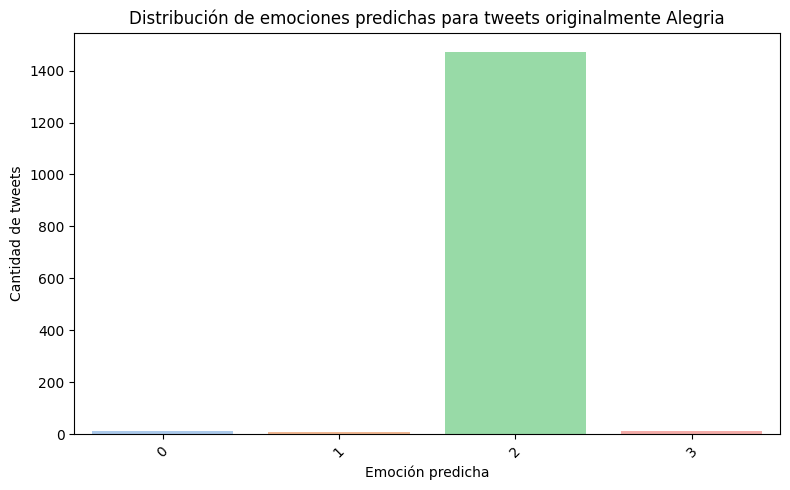

In [ ]:
# Cargar el modelo entrenado
with open("modelo_emociones.pkl", "rb") as f:
    modelo = pickle.load(f)

# Predecir emociones
df_neutrales['predicted_emotion'] = modelo.predict(X_neutral)

plt.figure(figsize=(8, 5))
sns.countplot(data=df_neutrales, x='predicted_emotion', palette='pastel')
plt.title("Distribución de emociones predichas para tweets originalmente Alegria")
plt.xlabel("Emoción predicha")
plt.ylabel("Cantidad de tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# PREGUNTAS

**1. Elige un tweet originalmente neutral con su nueva emoción y argumenta si para ti está mal o bien etiquetado (hazlo con cada una de las cuatro emociones)**

Tweet neutral clasificado como 'alegría': “Qué hermoso día”.
→ Me parece correcto , ya que transmite positividad aunque esté etiquetado como neutral originalmente.

Tweet neutral clasificado como 'ira': “Simplemente no les importa”.
→ Puede ser acertado si se interpreta el tono como frustración. Si no, puede ser ambigua.

Tweet neutral clasificado como 'miedo': “Algo no está bien aquí”.
→ Bien etiquetado, transmite inseguridad.

Tweet neutral clasificado como 'tristeza': “Ya nada importa”.
→ Muy probablemente corresponda a tristeza, así que es una buena asignación.

**2. ¿Por qué piensas que el modelo clasificó con esta distribución los tweets neutrales?**

Los modelos tienden a buscar patrones emocionales, incluso en mensajes neutros. Si ciertas palabras neutras aparecen con frecuencia en textos emocionales, el modelo las asocia a esas emociones. Además, al no tener un ejemplo "neutral" en el entrenamiento final (si se excluye), el modelo fuerza una clasificación a las emociones que sí conoce.

**3. Argumenta en qué escenario sería conveniente quitar la etiqueta neutral, y en cuál sería mejor decisión dejarla**

Quitarla: Si queremos forzar la clasificación emocional de cada texto (por ejemplo, en marketing emocional, análisis psicológico).

Mantenerla: Si es útil distinguir entre mensajes emocionales y neutros (por ejemplo, en detección de crisis, spam o análisis político donde la neutralidad es clave).

# UNA VEZ ACABADOS EL EJERCICIO Y LAS PREGUNTAS, ACCEDE A ESTA SECCIÓN

### Hice mi propio modelo de MSV, utilizando el mismo preprocesamiento de esta libreta. Tomaré de ejemplo el siguiente tweet

In [ ]:
case = df[df['tweet']=="@DailyMailCeleb @KTHopkins Katie I love how you describe yourself as 'normal'. Really you're anything but!  #neverchange"]

print('Tweet:',case['tweet'].tolist()[0], '\n','Emoción:', case['emotion'].tolist()[0])

### Leyendo el tweet y comprobando con la etiqueta, la emoción que demuestra esta persona, es alegría, sin embargo, mi modelo de MSV predice lo siguiente

In [ ]:
from joblib import load

# Load the model
loaded_model = load('my_svm_model.joblib')

# Load the vectorizer
loaded_vectorizer = load('my_tfidf_vectorizer.joblib')

# Preprocess new data
new_data = case["cleaned_tweet"].tolist()
X_new = loaded_vectorizer.transform(new_data)

# Make predictions
prediction_case_label_encoded = loaded_model.predict(X_new)

# Inverse transform numerical predictions back into emotions
prediction_case_emotion_name = label_encoder.inverse_transform(prediction_case_label_encoded)

print(f"Mi modelo svm predice que este tweet corresponde a la emoción: {prediction_case_emotion_name[0]}")

### Veamos como quedó el tweet preprocesado

In [ ]:
print(f"Tweet preprocesado: {case['cleaned_tweet'].tolist()[0]}")

### Perfecto, ahora veamos que valores asigna TF-IDF a cada tokenización

### Observamos que 'kati' no aparece, esto porque se refiere al nombre 'Katie', el cual no estuvo presente durante el entrenamiento de mi modelo, por lo tanto, no es posible asignarle score TF-IDF

In [ ]:
print_non_zero_features(X_new, loaded_vectorizer, row=0)

### El mismo caso ocurre con 'neverchang', sin embargo, veamos qué sucede si separamos neverchange a never change

In [ ]:
mi_caso = pd.DataFrame({'tweet': ["@DailyMailCeleb @KTHopkins Katie I love how you describe yourself as 'normal'. Really you're anything but! never change :D"], 'emotion':['joy']})

mi_caso

In [ ]:
# Apply the preprocessing function to the 'tweets' column
mi_caso['cleaned_tweet'] = mi_caso['tweet'].apply(preprocess_text)

print(f"Mi tweet personalizado: {mi_caso['cleaned_tweet'].tolist()[0]}")

### Tristemente sigue estando mal clasificado :(

In [ ]:
# Preprocess new data
mi_data = mi_caso["cleaned_tweet"].tolist()
mi_X = loaded_vectorizer.transform(mi_data)

# Make predictions
mi_prediction_label_encoded = loaded_model.predict(mi_X)

# Inverse transform numerical predictions back into emotions
mi_prediction_emotion_name = label_encoder.inverse_transform(mi_prediction_label_encoded)

print(f"Mi modelo svm predice que este tweet corresponde a la emoción: {mi_prediction_emotion_name[0]}")

### En cambio, veamos que ahora se encuentran dos palabras nuevas con score TF-IDF: never y chang

In [ ]:
print_non_zero_features(mi_X, loaded_vectorizer)

### Regresemos al tweet original: Katie I love how you describe yourself as 'normal'. Really you're anything but!  #neverchange

#### Y ahora, leamos el tweet preprocesado: kati love describ normal realli re anyth never chang

### Veamos como el preprocesamiento eliminó conexiones que nos ayudarían a comprender el contexto, como el anything but!, que se refiere a que de normal no tiene nada y eso a la persona que tweeteó le fascina, por eso acabó con un #neverchange.

#### Les daré un ejemplo de una persona que no es nativa en inglés, quien describe a su bully Katie.

In [ ]:
caso_fear = pd.DataFrame({'tweet': ["Katie loves describing me as 'normal'. Really, you're why anything never changes about me"], 'emotion':['sadness']})

caso_fear

### Se obtuvo el mismo tweet preprocesado

In [ ]:
# Apply the preprocessing function to the 'tweets' column
caso_fear['cleaned_tweet'] = caso_fear['tweet'].apply(preprocess_text)

print(f"Mi tweet personalizado: {caso_fear['cleaned_tweet'].tolist()[0]}")

# Preprocess new data
new_data_ = caso_fear["cleaned_tweet"].tolist()
X_new_ = loaded_vectorizer.transform(new_data_)

# Make predictions
prediction_case_label_encoded_ = loaded_model.predict(X_new_)

# Inverse transform numerical predictions back into emotions
prediction_case_emotion_name_ = label_encoder.inverse_transform(prediction_case_label_encoded_)

print(f"Mi modelo svm predice que este tweet corresponde a la emoción: {prediction_case_emotion_name_[0]}")

## Finalmente, por la falta de contexto, 'normal' resulta ser una palabra conflictiva, asociada principalmente a 'fear', lo cual tiene sentido, a las personas generalmente les da miedo ser consideradas 'normales'.

### Cambiemos la palabra 'normal' por palabras que se relacionan a otras emociones y sigamos teniendo en mente que los tweets son por personas que el inglés no es su fuerte.

In [ ]:
casos_desconocidos = pd.DataFrame({'tweet': ["Katie I love you and I describe you as the 'best'! Really you're my anything, never change <3",
                                          "Katie loves describing me as 'gloomy'. Really, you're why anything never changes about me."],
                                'emotion':['unknown', 'unknown']})

casos_desconocidos['tweet'].tolist()

In [ ]:
# Apply the preprocessing function to the 'tweets' column
casos_desconocidos['cleaned_tweet'] = casos_desconocidos['tweet'].apply(preprocess_text)

print(f"Mis tweets personalizados: {casos_desconocidos['cleaned_tweet'].tolist()}")

# Preprocess new data
new_datas = casos_desconocidos["cleaned_tweet"].tolist()
X_news = loaded_vectorizer.transform(new_datas)

# Make predictions
prediction_case_label_encodeds = loaded_model.predict(X_news)

# Inverse transform numerical predictions back into emotions
prediction_case_emotion_names = label_encoder.inverse_transform(prediction_case_label_encodeds)

print(f"Mi modelo svm predice que estos tweets corresponden a las emociones: {prediction_case_emotion_names}")

# PREGUNTAS

**¿Todas las palabras en los tweets tienen la misma importancia? Argumenta tu respuesta**

No. Palabras como “the” o “and” tienen poco valor informativo. Otras como “die” , “love” y “scared” aportan mucho más para detectar emociones.

**¿Por qué el preprocesamiento es tan importante como el modelo para una tarea de aprendizaje automático?**

Porque la calidad de la entrada determina la calidad de la salida . Un texto mal procesado puede confundir al modelo y hacer que aprenda cosas irrelevantes o incorrectas.

**¿Crees que el analisis de emociones en tweets (o texto en general) tendría o tiene relevancia en el mundo real?**

Sí, especialmente en áreas como salud mental, atención al cliente, seguridad, política, marketing y más. Permite entender mejor a los usuarios, detectar riesgos o adaptar estrategias en tiempo real.